# RAG 실험 결과 분석 노트북

**이 노트북은 실험을 다시 돌리지 않습니다.**

이미 `run_rag_chat.py --evaluate`로 생성된 `experiments/rag_*/` 폴더의 산출물만 읽어서
비교·시각화·진단합니다. 실험이 끝난 뒤 열어서 "어떤 Config가 제일 좋았는지" 한눈에 확인하세요.

---

### 분석 흐름

| 단계 | 섹션 | 확인하는 것 |
| --- | --- | --- |
| 발견 | ①~② | 어떤 실험들이 있는지 자동 탐색, 비교 대상 선택 |
| 지표 | ③~④ | 4개 metric 비교 막대그래프 + Before/After delta |
| 원인 | ⑤ | 실험 간 Config가 어떻게 다른지 (왜 점수가 달라졌는지) |
| 내용 | ⑥ | 같은 질문에 실험마다 뭐라고 답했는지 side-by-side |
| 질문별 | ⑦ | 질문×실험 hit/miss 히트맵 (어떤 질문이 자주 실패하나) |
| 검색 | ⑧ | retriever 방식(keyword/semantic/hybrid)별 성능 비교 |
| 실패 | ⑨ | 실패 유형(bad_retrievals/unsupported/failed) 통계 |
| 상세 | ⑩ | 한 실험 깊게 파고들기 (검색 결과·실패 질문·답변 상태) |
| 저장 | ⑪ | HTML로 내보내서 실험 리포트로 남기기 |

---

### 사용법

1. `rag_config_run.ipynb`로 실험을 먼저 돌립니다
2. 이 노트북을 열고 Shift+Enter로 셀을 순서대로 실행합니다
3. 마지막에 File > Download as > HTML 로 아티팩트를 남깁니다

---
## ① 실험 목록 자동 탐색

`experiments/` 폴더 아래에서 `metrics.json`이 존재하는 디렉터리만 실험으로 인식합니다.
ingest만 하고 evaluate는 안 한 폴더는 자동으로 제외됩니다.

In [1]:
# ===== 라이브러리 및 기본 설정 =====
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from collections import Counter

def find_project_root(start: Path) -> Path:
    """AGENTS.md, configs/, scripts/, src/ 가 있는 디렉터리를 프로젝트 루트로 판정"""
    markers = ("AGENTS.md", "configs", "scripts", "src")
    for candidate in (start, *start.parents):
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise RuntimeError("프로젝트 루트를 찾지 못했습니다.")

PROJECT_ROOT = find_project_root(Path.cwd()).resolve()
EXPERIMENTS_ROOT = PROJECT_ROOT / "experiments"

# ===== 실험 폴더 자동 수집 =====
# metrics.json 파일이 있는 폴더만 "완료된 실험"으로 간주
EXPERIMENT_DIRS = sorted([
    d for d in EXPERIMENTS_ROOT.iterdir()
    if d.is_dir() and (d / "metrics.json").exists()
])

# ===== 결과 출력 =====
if not EXPERIMENT_DIRS:
    print("⚠ metrics.json이 있는 실험 폴더가 없습니다.")
    print("  먼저 실험 노트북이나 run_rag_chat.py --evaluate 를 실행하세요.")
else:
    print(f"발견된 실험: {len(EXPERIMENT_DIRS)}개")
    for d in EXPERIMENT_DIRS:
        # 각 실험의 문서 수, chunk 수도 함께 표시
        docs_path = d / "parsed_documents.csv"
        chunks_path = d / "chunks.csv"
        doc_count = len(pd.read_csv(docs_path)) if docs_path.exists() else "?"
        chunk_count = len(pd.read_csv(chunks_path)) if chunks_path.exists() else "?"
        print(f"  {d.name}/  (문서 {doc_count}건, chunk {chunk_count}개)")

발견된 실험: 1개
  rag_keyword/  (문서 3건, chunk 3개)


---
## ② 비교 대상 선택

기본값은 **모든 실험 전체 비교**입니다.
특정 실험만 보고 싶으면 `SELECTED` 리스트를 수동으로 지정하세요.

아래 셀을 실행하면 각 실험의 `metrics.json`을 한 번에 불러와서 DataFrame으로 만듭니다.

In [2]:
# ===== 비교 대상 선택 =====
# 기본: 모든 실험
# 수동 지정 예시:
#   SELECTED = ["rag_langchain", "rag_hybrid"]
#   SELECTED = [d.name for d in EXPERIMENT_DIRS if "chunk" in d.name]
SELECTED = [d.name for d in EXPERIMENT_DIRS]
print(f"선택된 실험: {SELECTED}")

# ===== 모든 실험의 metrics.json을 하나의 DataFrame으로 =====
all_metrics = []
for exp_name in SELECTED:
    mp = EXPERIMENTS_ROOT / exp_name / "metrics.json"
    if mp.exists():
        m = json.loads(mp.read_text(encoding="utf-8"))
        m["experiment"] = exp_name       # 행 식별용 컬럼 추가
        all_metrics.append(m)

df_metrics = pd.DataFrame(all_metrics).set_index("experiment")
df_metrics

선택된 실험: ['rag_keyword']


,retrieval_hit_rate,answer_contains_expected_rate,citation_correct_rate,not_found_rate
experiment,,,,
rag_keyword,1.0,1.0,1.0,0.0


---
## ③ 지표 비교 — Grouped Bar Chart

**4개 평가 지표를 모든 실험에 대해 나란히 비교합니다.**

| 지표 | 의미 | 높을수록 |
| --- | --- | --- |
| `retrieval_hit_rate` (초록) | 검색된 chunk 중에 정답 chunk가 포함됐는가 | 좋음 |
| `answer_contains_expected_rate` (파랑) | 답변에 정답 키워드가 포함됐는가 | 좋음 |
| `citation_correct_rate` (주황) | citation이 정확한 chunk를 가리키는가 | 좋음 |
| `not_found_rate` (빨강) | 근거를 못 찾아 fallback한 비율 | **낮을수록** 좋음 |

→ 이것만 봐도 "어떤 Config가 종합적으로 우수한지" 판단할 수 있습니다.

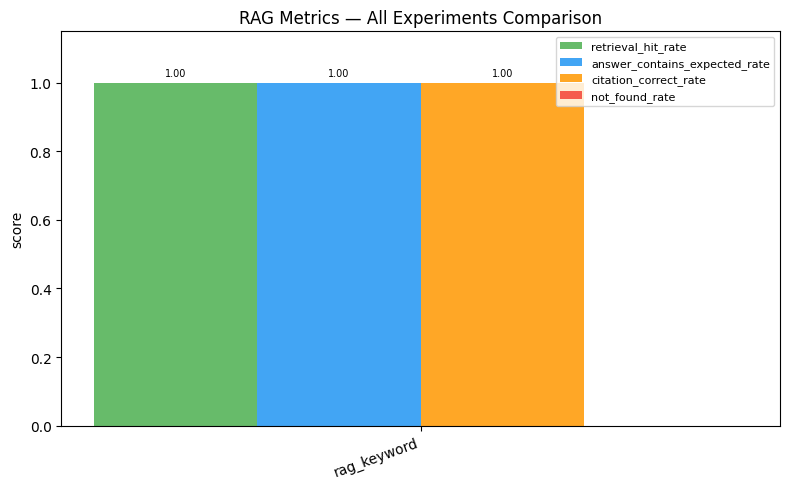

In [3]:
if df_metrics.empty:
    print("표시할 데이터가 없습니다. 먼저 실험을 실행하세요.")
else:
    # ===== 그래프 설정 =====
    metric_names = ["retrieval_hit_rate", "answer_contains_expected_rate",
                    "citation_correct_rate", "not_found_rate"]
    n_exp = len(df_metrics)   # 실험 개수에 따라 그래프 폭 자동 조절
    fig, ax = plt.subplots(figsize=(max(8, n_exp * 1.8), 5))
    x = range(n_exp)
    bar_width = 0.2
    colors = ["#4CAF50", "#2196F3", "#FF9800", "#F44336"]

    # ===== 지표별 막대 그리기 =====
    for i, (metric, color) in enumerate(zip(metric_names, colors)):
        values = [df_metrics.loc[name, metric] if name in df_metrics.index else 0
                  for name in SELECTED]
        bars = ax.bar([pos + i * bar_width for pos in x], values, bar_width,
                      label=metric, color=color, alpha=0.85)
        # 막대 위에 수치 표시 (값이 0보다 클 때만)
        for bar, val in zip(bars, values):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.02, f"{val:.2f}",
                        ha="center", fontsize=7)

    ax.set_ylabel("score")
    ax.set_title("RAG Metrics — All Experiments Comparison")
    ax.set_xticks([pos + bar_width * 1.5 for pos in x])
    ax.set_xticklabels(SELECTED, rotation=20, ha="right")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_ylim(0, 1.15)
    plt.tight_layout()
    plt.show()

---
## ④ 2개 실험 Before/After 비교

"Config A → Config B로 바꾸니 어떤 지표가 얼마나 올랐는가"를 delta로 보여줍니다.
기본값은 SELECTED의 첫 2개이지만, `A`, `B` 변수를 직접 지정해도 됩니다.

In [4]:
# ===== 비교할 두 실험 선택 =====
if len(SELECTED) >= 2:
    A, B = SELECTED[0], SELECTED[1]   # 자동: 앞 2개
else:
    A, B = SELECTED[0], SELECTED[0]
# 수동 지정하려면: A, B = "rag_langchain", "rag_hybrid"

print(f"Before: {A}")
print(f"After : {B}")

if A in df_metrics.index and B in df_metrics.index:
    rows = []
    for metric in ["retrieval_hit_rate", "answer_contains_expected_rate",
                   "citation_correct_rate", "not_found_rate"]:
        a_val = df_metrics.loc[A, metric]
        b_val = df_metrics.loc[B, metric]
        delta = b_val - a_val
        # delta 방향 표시 (not_found_rate는 감소가 좋음에 주의!)
        if metric == "not_found_rate":
            emoji = "+ " if delta < -0.01 else "- " if delta > 0.01 else "= "  # 감소=좋음
        else:
            emoji = "+ " if delta > 0.03 else "- " if delta < -0.03 else "= "
        rows.append({
            "metric": metric,
            A: f"{a_val:.3f}",
            B: f"{b_val:.3f}",
            "delta": f"{delta:+.3f} {emoji}",
        })
    display(pd.DataFrame(rows))
else:
    print("비교할 데이터가 부족합니다.")

Before: rag_keyword
After : rag_keyword


,metric,rag_keyword,delta
0,retrieval_hit_rate,1.000,+0.000 =
1,answer_contains_expected_rate,1.000,+0.000 =
2,citation_correct_rate,1.000,+0.000 =
3,not_found_rate,0.000,+0.000 =


---
## ⑤ Config 차이점 비교

"A 실험과 B 실험의 점수 차이가 왜 발생했는가?" → Config를 비교해서 원인을 추적합니다.
각 실험 폴더에 저장된 `config.yaml`에서 RAG 관련 주요 키만 추출해서 표로 보여줍니다.

In [5]:
def load_config_yaml(exp_name):
    """실험 폴더에서 config.yaml을 불러옵니다."""
    path = EXPERIMENTS_ROOT / exp_name / "config.yaml"
    if path.exists():
        return yaml.safe_load(path.read_text(encoding="utf-8"))
    return {}

if len(SELECTED) >= 2:
    # ===== 비교할 Config 키 목록 =====
    keys_of_interest = [
        ("rag", "engine"),                     # 사용 엔진 (langchain / local)
        ("rag", "splitter", "chunk_size"),     # chunk 크기
        ("rag", "splitter", "chunk_overlap"),   # chunk 간 중첩
        ("rag", "embedding", "provider"),       # 임베딩 방식
        ("rag", "embedding", "model_name"),     # 임베딩 모델명
        ("rag", "retriever", "method"),          # 검색 방식 (keyword/semantic/hybrid)
        ("rag", "retriever", "top_k"),           # 검색 결과 개수
        ("rag", "answerer", "provider"),         # 답변 생성 방식
        ("rag", "answerer", "model_name"),       # LLM 모델명
        ("rag", "reranker", "enabled"),          # 재정렬 사용 여부
    ]

    # ===== 각 실험의 config를 읽어서 테이블로 =====
    configs = {name: load_config_yaml(name) for name in SELECTED[:4]}
    config_rows = []
    for key_path in keys_of_interest:
        label = ".".join(key_path)
        row = {"config_key": label}
        all_same = True
        first_val = None
        for name in SELECTED[:4]:
            val = configs.get(name, {})
            for k in key_path:
                val = val.get(k, {}) if isinstance(val, dict) else val
            row[name] = str(val) if val is not None else "-"
            if first_val is None:
                first_val = row[name]
            elif row[name] != first_val:
                all_same = False
        # 모든 실험에서 값이 같으면 표시
        row["diff?"] = "" if all_same else "← 차이 있음"
        config_rows.append(row)

    df_config = pd.DataFrame(config_rows)
    print("아래 표에서 'diff?' 컬럼이 표시된 행이 실험 간 차이가 있는 Config 항목입니다.")
    display(df_config)
else:
    print("비교할 실험이 2개 이상 필요합니다.")

비교할 실험이 2개 이상 필요합니다.


---
## ⑥ 답변 텍스트 비교 (Side-by-Side)

**가장 직관적인 비교**: 같은 질문에 대해 각 실험이 **뭐라고 답했는지** 직접 나열합니다.
점수만 보면 놓칠 수 있는 "답변 품질의 차이"를 텍스트로 확인할 수 있습니다.

모든 실험에 공통으로 존재하는 질문만 비교하며, 최대 10개까지 표시합니다.

In [6]:
# ===== 각 실험의 answers.jsonl을 질문별 dict로 로드 =====
all_answers = {}
for exp_name in SELECTED[:4]:          # 최대 4개 실험까지 비교
    ans_path = EXPERIMENTS_ROOT / exp_name / "answers.jsonl"
    if ans_path.exists():
        lines = ans_path.read_text(encoding="utf-8").splitlines()
        answers = [json.loads(line) for line in lines if line.strip()]
        all_answers[exp_name] = {a["question"]: a for a in answers}

if len(all_answers) >= 2:
    exp_names = list(all_answers.keys())

    # ===== 모든 실험에 공통으로 존재하는 질문만 추출 =====
    common_questions = set.intersection(*[set(a.keys()) for a in all_answers.values()])
    common_questions = sorted(common_questions)[:10]   # 최대 10개

    if common_questions:
        print(f"공통 질문 {len(common_questions)}건 비교:\n")
        for i, q in enumerate(common_questions, 1):
            print(f"[{i}] 질문: {q}")
            print("-" * 60)
            for exp_name in exp_names:
                a = all_answers[exp_name].get(q, {})
                ans_text = a.get("answer", "(답변 없음)")
                # 답변이 길면 100자만 표시
                preview = ans_text[:100] + "..." if len(ans_text) > 100 else ans_text
                status = a.get("status", "?")
                print(f"  [{exp_name}] ({status}): {preview}")
            print()
    else:
        print("공통 질문이 없습니다. 각 실험의 평가 질문 CSV가 다를 수 있습니다.")
else:
    print("비교할 실험이 2개 이상 필요합니다.")

비교할 실험이 2개 이상 필요합니다.


---
## ⑦ 질문별 Hit/Miss 히트맵

**질문×실험 행렬**로 어떤 질문이 어떤 실험에서 retrieval에 성공/실패했는지 시각화합니다.
- 초록색(HIT): 정답 chunk가 top-k 안에 들어옴
- 빨간색(MISS): 정답 chunk를 검색하지 못함

→ 한눈에 "이 질문은 모든 실험에서 실패하네 → chunk 구조 자체가 문제" 같은 패턴 파악이 가능합니다.

In [7]:
# ===== 각 실험의 evaluation_results.csv 로드 =====
all_evals = {}
for exp_name in SELECTED[:6]:
    eval_path = EXPERIMENTS_ROOT / exp_name / "evaluation_results.csv"
    if eval_path.exists():
        df = pd.read_csv(eval_path)
        all_evals[exp_name] = df

if len(all_evals) >= 2:
    # ===== 모든 실험에서 공통으로 존재하는 질문만 =====
    common_qs = set.intersection(*[set(df["question"]) for df in all_evals.values()])
    common_qs = sorted(common_qs)[:15]

    if common_qs:
        # ===== 질문×실험 hit(1)/miss(0) 행렬 생성 =====
        heatmap_data = {}
        for exp_name, df in all_evals.items():
            df_q = df[df["question"].isin(common_qs)].set_index("question")
            heatmap_data[exp_name] = (df_q["retrieval_hit"] == "true").astype(int)
        df_heat = pd.DataFrame(heatmap_data)

        # ===== 히트맵 그리기 =====
        fig, ax = plt.subplots(figsize=(max(6, len(df_heat.columns)*1.5),
                                       max(4, len(df_heat)*0.35)))
        im = ax.imshow(df_heat.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
        ax.set_xticks(range(len(df_heat.columns)))
        ax.set_xticklabels(df_heat.columns, rotation=30, ha="right")
        ax.set_yticks(range(len(df_heat.index)))
        ax.set_yticklabels([q[:40] for q in df_heat.index], fontsize=9)
        ax.set_title("Retrieval Hit Heatmap (초록=HIT, 빨강=MISS)")

        # 각 셀에 HIT/MISS 텍스트 표시
        for i in range(len(df_heat.index)):
            for j in range(len(df_heat.columns)):
                val = df_heat.values[i, j]
                text_color = "black" if val else "darkred"
                ax.text(j, i, "HIT" if val else "MISS", ha="center", va="center",
                        fontsize=7, color=text_color, fontweight="bold")
        plt.tight_layout()
        plt.show()
    else:
        print("공통 질문이 없습니다.")
else:
    print("evaluation_results.csv가 2개 이상 필요합니다.")

evaluation_results.csv가 2개 이상 필요합니다.


---
## ⑧ Retriever 방식별 비교

`compare_rag_retrievers.py`를 실행하면 생성되는 `reports/rag_retriever_comparison.csv`를 불러와
keyword vs semantic vs hybrid의 성능을 비교합니다.

*이 파일이 없으면 이 셀은 건너뜁니다.*

In [8]:
COMPARISON_CSV = PROJECT_ROOT / "reports" / "rag_retriever_comparison.csv"

if COMPARISON_CSV.exists():
    df_comp = pd.read_csv(COMPARISON_CSV)
    print("=== Retriever별 metric 테이블 ===")
    display(df_comp)

    # 차트로 시각화
    if not df_comp.empty and "experiment" in df_comp.columns:
        metric_cols = [c for c in ["retrieval_hit_rate",
                       "answer_contains_expected_rate", "citation_correct_rate"]
                       if c in df_comp.columns]
        if metric_cols:
            df_comp.set_index("experiment")[metric_cols].plot.bar(
                figsize=(10, 5), color=["#4CAF50", "#2196F3", "#FF9800"],
                title="Retriever Method Comparison")
            plt.ylabel("score"); plt.ylim(0, 1.1)
            plt.xticks(rotation=0); plt.tight_layout(); plt.show()
else:
    print("rag_retriever_comparison.csv 파일이 없습니다.")
    print("생성 명령어: python scripts/compare_rag_retrievers.py --project-root .")

rag_retriever_comparison.csv 파일이 없습니다.
생성 명령어: python scripts/compare_rag_retrievers.py --project-root .


---
## ⑨ 실패 분석 통합

모든 실험의 실패 CSV 3종(`bad_retrievals`, `unsupported_answers`, `failed_questions`)을 모아서
실패 건수를 실험별로 비교합니다.

| 실패 유형 | 의미 |
| --- | --- |
| `bad_retrievals` (주황) | 정답 chunk가 top-k에 없음 → **retriever/chunk 문제** |
| `unsupported_answers` (파랑) | 답변했지만 citation이 틀리거나 expected_answer 미포함 → **answerer 문제** |
| `failed_questions` (빨강) | 실행 중 예외 발생 → **파이프라인 오류** |

In [9]:
failure_types = ["bad_retrievals", "unsupported_answers", "failed_questions"]
failure_summary = []

for exp_name in SELECTED:
    row = {"experiment": exp_name}
    for ftype in failure_types:
        path = EXPERIMENTS_ROOT / exp_name / f"{ftype}.csv"
        # 파일이 있고 내용이 있으면 개수, 없으면 0
        if path.exists():
            try:
                row[ftype] = len(pd.read_csv(path))
            except Exception:
                row[ftype] = 0
        else:
            row[ftype] = 0
    failure_summary.append(row)

df_fail = pd.DataFrame(failure_summary).set_index("experiment")

if df_fail.empty or df_fail.sum().sum() == 0:
    print("모든 실험에서 실패 케이스가 없습니다!")
else:
    print("=== 실패 건수 테이블 ===")
    display(df_fail)

    # 바 차트
    df_fail.plot.bar(figsize=(10, 4),
                     color=["#FF9800", "#2196F3", "#F44336"],
                     title="Failure Case Breakdown by Experiment")
    plt.ylabel("count"); plt.xticks(rotation=20, ha="right")
    plt.tight_layout(); plt.show()

모든 실험에서 실패 케이스가 없습니다!


---
## ⑩ 특정 실험 상세 진단

한 실험을 골라서 **깊게** 파고듭니다:
- 실제 검색 결과가 어떤 chunk를 가져왔는지
- 어떤 질문이 검색에 실패했는지 (expected_answer와 함께)
- 답변 상태 분포 (answered / not_found / error)

In [10]:
# ===== 분석할 실험 선택 =====
DETAIL_EXP = SELECTED[0]   # 기본값: 첫 번째 실험
# 수동 지정: DETAIL_EXP = "rag_langchain"
DETAIL_DIR = EXPERIMENTS_ROOT / DETAIL_EXP
print(f"=== [{DETAIL_EXP}] 상세 분석 ===\n")

# ===== 1) Chunk 통계 =====
chunks_path = DETAIL_DIR / "chunks.csv"
if chunks_path.exists():
    chunks = pd.read_csv(chunks_path)
    print(f"[문서/chunk] 총 {chunks['document_id'].nunique()}개 문서, {len(chunks)}개 chunk")
    if "token_count" in chunks.columns:
        tc = chunks["token_count"].astype(int)
        print(f"  chunk 길이: min={tc.min()}, max={tc.max()}, mean={tc.mean():.0f}")

# ===== 2) 검색 결과 미리보기 =====
ret_path = DETAIL_DIR / "retrieval_results.jsonl"
if ret_path.exists():
    rows = [json.loads(line) for line in
            ret_path.read_text(encoding="utf-8").splitlines() if line.strip()]
    print(f"\n[검색] 총 {len(rows)}건, 첫 3건 미리보기:")
    for r in rows[:3]:
        print(f"\n  Q: {r.get('question','?')}")
        chunks_found = r.get("retrieved_chunks", [])
        print(f"  검색 방식: {r.get('retriever_method','?')}, top-{r.get('top_k','?')}, 결과 {len(chunks_found)}건")
        for chunk in chunks_found[:2]:
            print(f"    [{chunk.get('rank','?')}등] score={chunk.get('score',0):.3f}"
                  f"  {chunk.get('chunk_id','?')}")
            print(f"           text: {chunk.get('text','')[:80]}...")

# ===== 3) 검색 실패 질문 =====
bad_path = DETAIL_DIR / "bad_retrievals.csv"
if bad_path.exists():
    bad = pd.read_csv(bad_path)
    if not bad.empty:
        print(f"\n[실패] 검색 실패 질문 ({len(bad)}건):")
        for _, row in bad.head(5).iterrows():
            print(f"  X {row.get('question','?')}")
            print(f"    expected_answer: {str(row.get('expected_answer','?'))[:60]}")
    else:
        print(f"\n[실패] 검색 실패 없음")

# ===== 4) 답변 상태 분포 =====
ans_path = DETAIL_DIR / "answers.jsonl"
if ans_path.exists():
    answers = [json.loads(line) for line in
               ans_path.read_text(encoding="utf-8").splitlines() if line.strip()]
    print(f"\n[답변] 총 {len(answers)}건, 상태 분포:")
    for status, count in Counter(a.get("status","?") for a in answers).items():
        print(f"  {status}: {count}건")

=== [rag_keyword] 상세 분석 ===

[문서/chunk] 총 1개 문서, 3개 chunk
  chunk 길이: min=10, max=15, mean=13

[검색] 총 15건, 첫 3건 미리보기:

  Q: 예산은 얼마야?
  검색 방식: keyword, top-3, 결과 1건
    [1등] score=2.500  rfp_sample_chunk_0001
           text: 본 사업의 예산은 5천만 원입니다. 사업 목적은 RFP 문서를 빠르게 분석하는 AI 챗봇을 구축하는 것입니다....

  Q: 예산은 얼마야?
  검색 방식: keyword, top-3, 결과 1건
    [1등] score=2.500  rfp_sample_chunk_0001
           text: 본 사업의 예산은 5천만 원입니다. 사업 목적은 RFP 문서를 빠르게 분석하는 AI 챗봇을 구축하는 것입니다....

  Q: 예산이 얼마야?
  검색 방식: keyword, top-3, 결과 1건
    [1등] score=1.000  rfp_sample_chunk_0001
           text: 본 사업의 예산은 5천만 원입니다. 사업 목적은 RFP 문서를 빠르게 분석하는 AI 챗봇을 구축하는 것입니다....

[실패] 검색 실패 없음

[답변] 총 12건, 상태 분포:
  answered: 12건


---
## ⑪ 아티팩트로 저장

분석이 끝난 후 HTML로 내보내면 (`File > Download as > HTML`)
차트 + 테이블 + 텍스트가 모두 포함된 실험 리포트가 됩니다.

`reports/` 폴더에 `analysis_YYYYMMDD.html` 형식으로 저장하는 것을 권장합니다.

In [11]:
from datetime import datetime

print("=" * 50)
print("  RAG 실험 분석 리포트")
print("=" * 50)
print(f"\n분석 일시: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"비교 실험: {len(SELECTED)}개")

if not df_metrics.empty:
    print(f"\n[지표 요약]")
    for metric in ["retrieval_hit_rate", "answer_contains_expected_rate",
                   "citation_correct_rate", "not_found_rate"]:
        if metric in df_metrics.columns:
            best_idx = df_metrics[metric].idxmax() if metric != "not_found_rate" else df_metrics[metric].idxmin()
            best_val = df_metrics.loc[best_idx, metric]
            print(f"  {metric}: 최고 {best_idx} ({best_val:.3f})")

print(f"\nHTML 저장 명령어 (터미널):")
print(f"  jupyter nbconvert --to html notebooks/rag/rag_compare_results.ipynb \\")
print(f"    --output reports/analysis_{datetime.now().strftime('%Y%m%d')}.html")

  RAG 실험 분석 리포트

분석 일시: 2026-06-18 07:14
비교 실험: 1개

[지표 요약]
  retrieval_hit_rate: 최고 rag_keyword (1.000)
  answer_contains_expected_rate: 최고 rag_keyword (1.000)
  citation_correct_rate: 최고 rag_keyword (1.000)
  not_found_rate: 최고 rag_keyword (0.000)

HTML 저장 명령어 (터미널):
  jupyter nbconvert --to html notebooks/rag/rag_compare_results.ipynb \
    --output reports/analysis_20260618.html
